In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data)

In [3]:
df.head()

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
# Делаем имена колонок такие же, как имена переменных:
df.columns = iris.feature_names

In [5]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


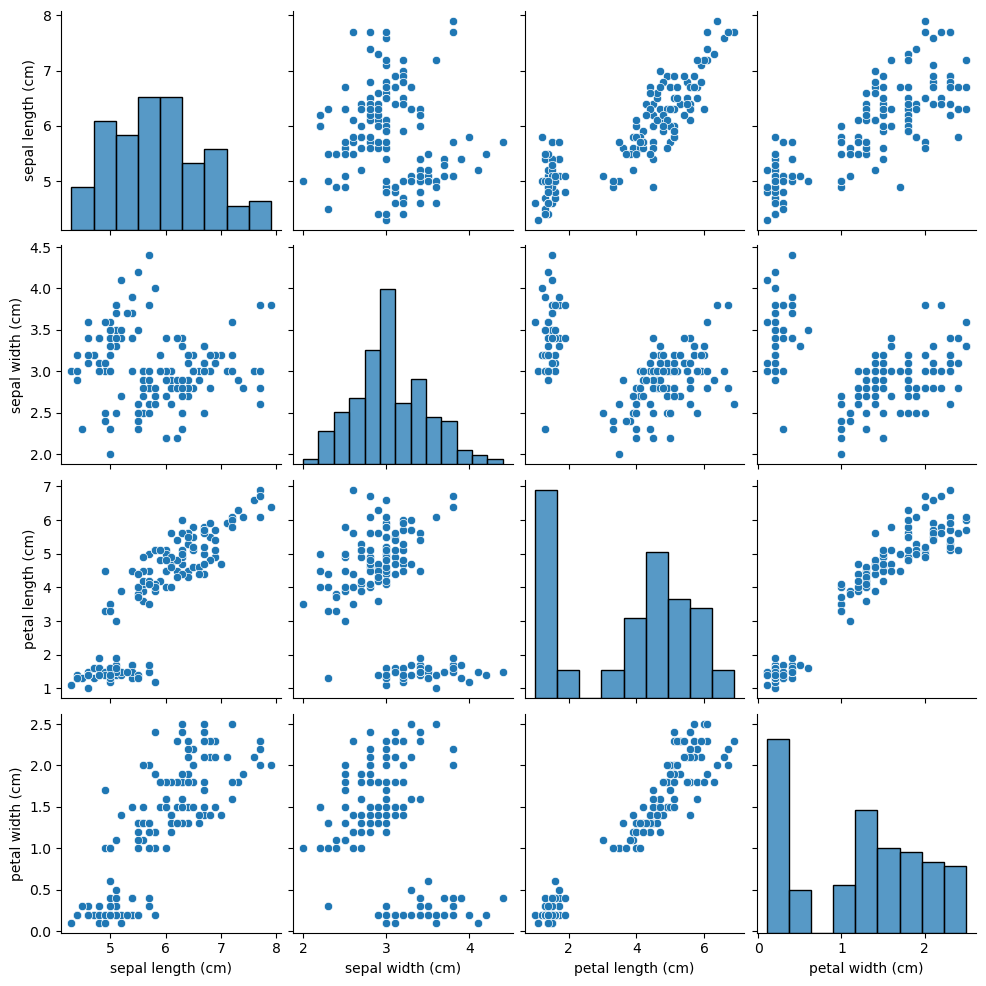

In [6]:
sns.pairplot(df)

<Axes: >

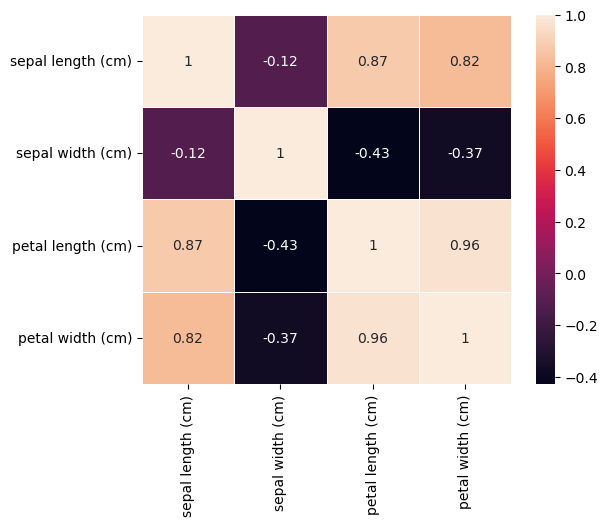

In [7]:
sns.heatmap(df.corr(), square=True, annot=True, linewidths=.5)

In [8]:
X = df.iloc[:, [2, 3]].values

Длина и ширина лепестков

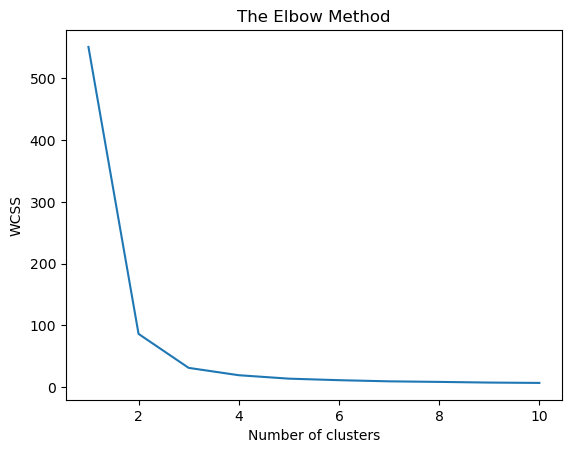

In [9]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## KMeans

In [10]:
kmeans = KMeans(init='k-means++', n_clusters=3, n_init=10)
kmeans.fit(X)

KMeans(n_clusters=3, n_init=10)

In [11]:
pred=kmeans.fit_predict(X)

In [12]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


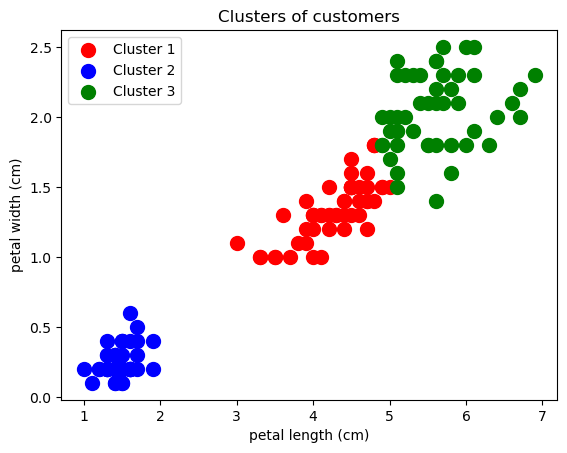

In [13]:
plt.scatter(X[pred == 0, 0], X[pred == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[pred == 1, 0], X[pred == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[pred == 2, 0], X[pred == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.title('Clusters of customers')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.show()

In [14]:
df2 = pd.DataFrame(iris.data)
df2.columns = iris.feature_names
df2['target'] = iris.target
df2['cluster'] = pd.Series(kmeans.labels_)

cluster
0    52
1    50
2    48
Name: count, dtype: int64


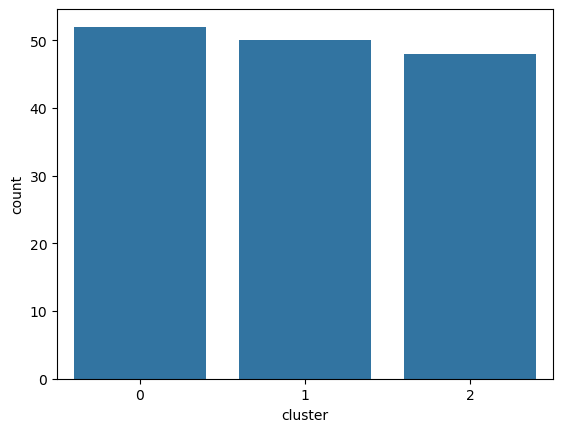

In [15]:
print(df2['cluster'].value_counts())
sns.countplot(x='cluster', data=df2)
plt.show()

In [16]:
df2[df2['target'] == 0].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


In [17]:
df2[df2['target'] == 1].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
50,7.0,3.2,4.7,1.4,1,0
51,6.4,3.2,4.5,1.5,1,0
52,6.9,3.1,4.9,1.5,1,0
53,5.5,2.3,4.0,1.3,1,0
54,6.5,2.8,4.6,1.5,1,0
55,5.7,2.8,4.5,1.3,1,0
56,6.3,3.3,4.7,1.6,1,0
57,4.9,2.4,3.3,1.0,1,0
58,6.6,2.9,4.6,1.3,1,0
59,5.2,2.7,3.9,1.4,1,0


In [18]:
df2[df2['target'] == 2].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
100,6.3,3.3,6.0,2.5,2,2
101,5.8,2.7,5.1,1.9,2,2
102,7.1,3.0,5.9,2.1,2,2
103,6.3,2.9,5.6,1.8,2,2
104,6.5,3.0,5.8,2.2,2,2
105,7.6,3.0,6.6,2.1,2,2
106,4.9,2.5,4.5,1.7,2,0
107,7.3,2.9,6.3,1.8,2,2
108,6.7,2.5,5.8,1.8,2,2
109,7.2,3.6,6.1,2.5,2,2


In [19]:
print(f'Кол-во совпадений target 0: {df2[(df2['target'] == 0) & (df2['cluster'] == 1)].shape[0] / 50}')
print(f'Кол-во совпадений target 1: {df2[(df2['target'] == 1) & (df2['cluster'] == 2)].shape[0] / 50}')
print(f'Кол-во совпадений target 2: {df2[(df2['target'] == 2) & (df2['cluster'] == 0)].shape[0] / 50}')

Кол-во совпадений target 0: 1.0
Кол-во совпадений target 1: 0.04
Кол-во совпадений target 2: 0.08


## Dendogram

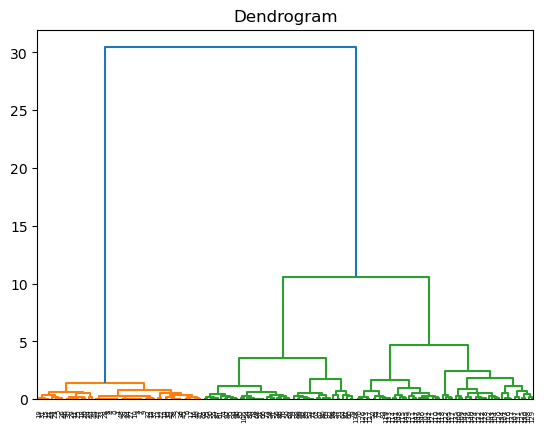

In [20]:
import scipy.cluster.hierarchy as sch
dendrogram = sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.title('Dendrogram')
plt.show()

In [21]:
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering(n_clusters = 3, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

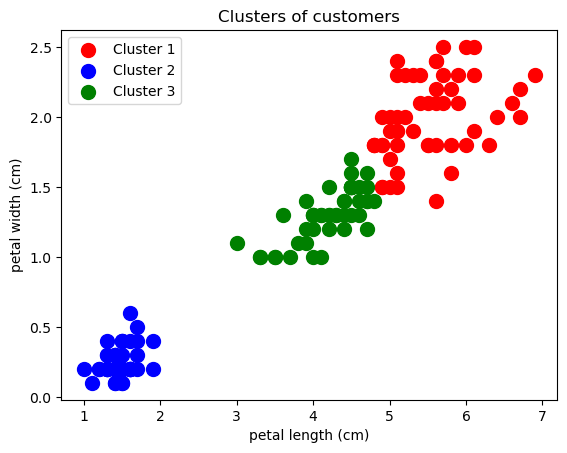

In [22]:
plt.scatter(X[y_hc == 0, 0], X[y_hc == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_hc == 1, 0], X[y_hc == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_hc == 2, 0], X[y_hc == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.title('Clusters of customers')
plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.legend()
plt.show()

In [23]:
df2 = pd.DataFrame(iris.data)
df2.columns = iris.feature_names
df2['target'] = iris.target
df2['cluster'] = pd.Series(hc.labels_)

cluster
0    54
1    50
2    46
Name: count, dtype: int64


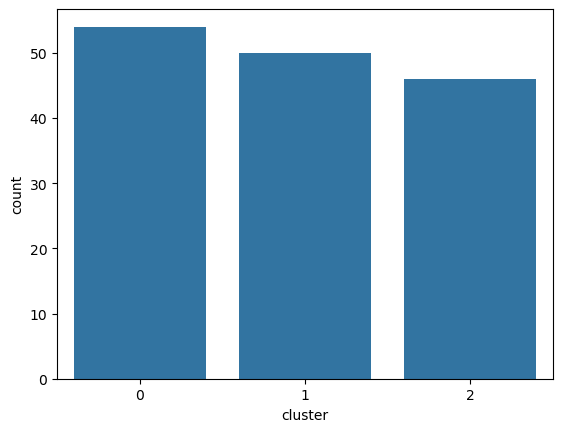

In [24]:
print(df2['cluster'].value_counts())
sns.countplot(x='cluster', data=df2)
plt.show()

In [25]:
df2[df2['target'] == 0].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,1
1,4.9,3.0,1.4,0.2,0,1
2,4.7,3.2,1.3,0.2,0,1
3,4.6,3.1,1.5,0.2,0,1
4,5.0,3.6,1.4,0.2,0,1
5,5.4,3.9,1.7,0.4,0,1
6,4.6,3.4,1.4,0.3,0,1
7,5.0,3.4,1.5,0.2,0,1
8,4.4,2.9,1.4,0.2,0,1
9,4.9,3.1,1.5,0.1,0,1


In [26]:
df2[df2['target'] == 1].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
50,7.0,3.2,4.7,1.4,1,2
51,6.4,3.2,4.5,1.5,1,2
52,6.9,3.1,4.9,1.5,1,0
53,5.5,2.3,4.0,1.3,1,2
54,6.5,2.8,4.6,1.5,1,2
55,5.7,2.8,4.5,1.3,1,2
56,6.3,3.3,4.7,1.6,1,2
57,4.9,2.4,3.3,1.0,1,2
58,6.6,2.9,4.6,1.3,1,2
59,5.2,2.7,3.9,1.4,1,2


In [27]:
df2[df2['target'] == 2].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
100,6.3,3.3,6.0,2.5,2,0
101,5.8,2.7,5.1,1.9,2,0
102,7.1,3.0,5.9,2.1,2,0
103,6.3,2.9,5.6,1.8,2,0
104,6.5,3.0,5.8,2.2,2,0
105,7.6,3.0,6.6,2.1,2,0
106,4.9,2.5,4.5,1.7,2,2
107,7.3,2.9,6.3,1.8,2,0
108,6.7,2.5,5.8,1.8,2,0
109,7.2,3.6,6.1,2.5,2,0


In [28]:
print(f'Кол-во совпадений target 0: {df2[(df2['target'] == 0) & (df2['cluster'] == 1)].shape[0] / 50}')
print(f'Кол-во совпадений target 1: {df2[(df2['target'] == 1) & (df2['cluster'] == 2)].shape[0] / 50}')
print(f'Кол-во совпадений target 2: {df2[(df2['target'] == 2) & (df2['cluster'] == 0)].shape[0] / 50}')

Кол-во совпадений target 0: 1.0
Кол-во совпадений target 1: 0.9
Кол-во совпадений target 2: 0.98


In [29]:
X = (X - X.mean(axis=0))/X.std(axis=0)

In [30]:
from sklearn.neighbors import NearestNeighbors
model = NearestNeighbors(n_neighbors=20, algorithm='ball_tree', metric='haversine')

In [31]:
model.fit(X)
dist, _ = model.kneighbors(X, n_neighbors=20, return_distance=True)

In [32]:
dist = dist[:, -1]

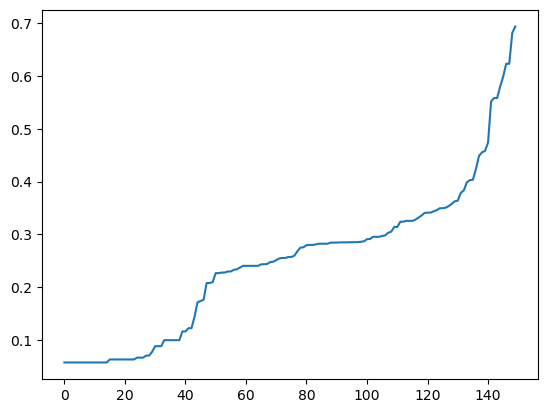

In [33]:
dist = np.sort(dist)
plt.plot(dist)

In [34]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=20, metric='haversine', algorithm='ball_tree')
dbscan.fit(X)

DBSCAN(algorithm='ball_tree', eps=0.2, metric='haversine', min_samples=20)

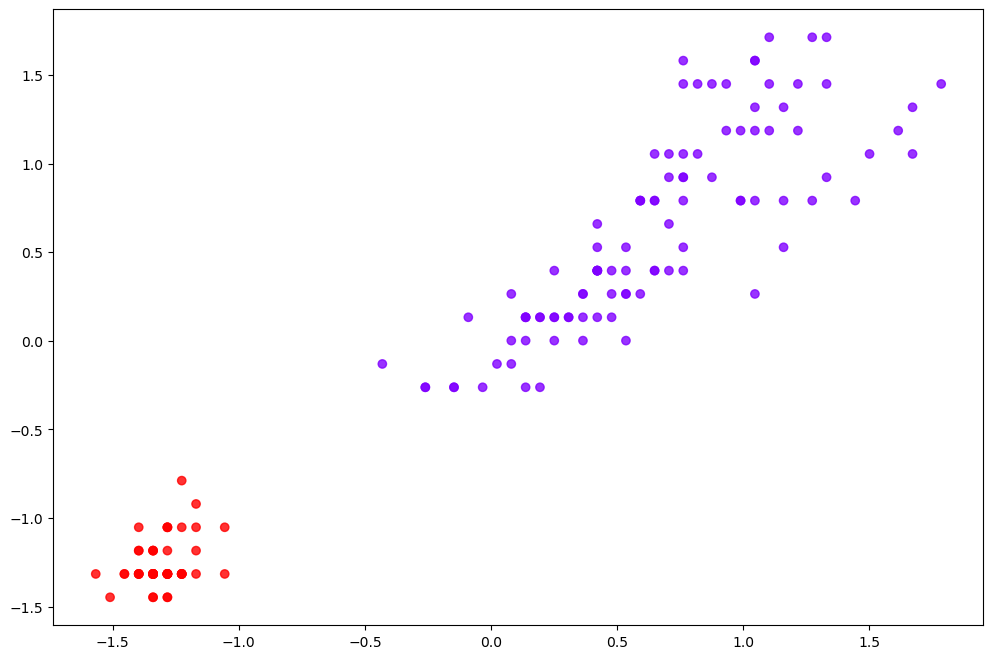

In [35]:
plt.figure(figsize=(12,8))
plt.scatter(X[:,0],X[:,1],c=dbscan.labels_,cmap='rainbow', alpha=0.8)

In [36]:
df2 = pd.DataFrame(iris.data)
df2.columns = iris.feature_names
df2['target'] = iris.target
df2['cluster'] = pd.Series(dbscan.labels_)

cluster
-1    100
 0     50
Name: count, dtype: int64


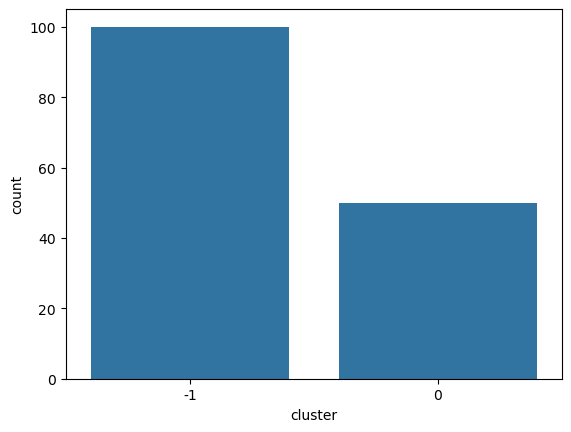

In [37]:
print(df2['cluster'].value_counts())
sns.countplot(x='cluster', data=df2)
plt.show()

In [38]:
df2[df2['target'] == 0].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
5,5.4,3.9,1.7,0.4,0,0
6,4.6,3.4,1.4,0.3,0,0
7,5.0,3.4,1.5,0.2,0,0
8,4.4,2.9,1.4,0.2,0,0
9,4.9,3.1,1.5,0.1,0,0


In [39]:
df2[df2['target'] == 1].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
50,7.0,3.2,4.7,1.4,1,-1
51,6.4,3.2,4.5,1.5,1,-1
52,6.9,3.1,4.9,1.5,1,-1
53,5.5,2.3,4.0,1.3,1,-1
54,6.5,2.8,4.6,1.5,1,-1
55,5.7,2.8,4.5,1.3,1,-1
56,6.3,3.3,4.7,1.6,1,-1
57,4.9,2.4,3.3,1.0,1,-1
58,6.6,2.9,4.6,1.3,1,-1
59,5.2,2.7,3.9,1.4,1,-1


In [40]:
df2[df2['target'] == 2].head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,cluster
100,6.3,3.3,6.0,2.5,2,-1
101,5.8,2.7,5.1,1.9,2,-1
102,7.1,3.0,5.9,2.1,2,-1
103,6.3,2.9,5.6,1.8,2,-1
104,6.5,3.0,5.8,2.2,2,-1
105,7.6,3.0,6.6,2.1,2,-1
106,4.9,2.5,4.5,1.7,2,-1
107,7.3,2.9,6.3,1.8,2,-1
108,6.7,2.5,5.8,1.8,2,-1
109,7.2,3.6,6.1,2.5,2,-1


In [90]:
print(f'Кол-во совпадений target 0: {df2[(df2['target'] == 0) & (df2['cluster'] == 0)].shape[0] / 50}')
print(f'Кол-во совпадений target 1: {df2[(df2['target'] == 1) & (df2['cluster'] == -1)].shape[0] / 50}')
print(f'Кол-во совпадений target 2: {df2[(df2['target'] == 2) & (df2['cluster'] == -1)].shape[0] / 50}')

Кол-во совпадений target 0: 1.0
Кол-во совпадений target 1: 1.0
Кол-во совпадений target 2: 1.0
